# Imports

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from olive_oil.data import load_dataset, average_replicates, get_spectral_matrix
from olive_oil.visualization import plot_spectra
from olive_oil.preprocessing import row_profile, log_transform, mean_center, snv, savgol_derivative, select_region

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [4]:
data = load_dataset("../Data/CAC2026_Data_challenge.xlsx")


## Data overview

In [5]:
for k in data.keys():
    print(k, data[k].shape)
    if len(data[k].columns) < 10:
        print(data[k].columns, "\n")
    else:
        print(data[k].columns[0], ", ", data[k].columns[1], "...", data[k].columns[-1], "\n")

labels (220, 2)
Index(['sample_id', 'label'], dtype='str') 

metadata (220, 5)
Index(['sample_id', 'Grade (Lampante, Virgin, Extra Virgin - Olive Oil)',
       'Fruity intensity', 'Bitterness', 'Pungency'],
      dtype='str') 

cal_uvvis (440, 702)
sample_id ,  300.0 ... 1000.0 

cal_ftir (660, 550)
sample_id ,  3230.23493314452 ... 673.046002228424 

cal_hsms (440, 302)
sample_id ,  50.0 ... 350.0 

test_uvvis (48, 702)
sample_id ,  300.0 ... 1000.0 

test_ftir (72, 550)
sample_id ,  3230.23493314452 ... 673.046002228424 

test_hsms (48, 302)
sample_id ,  50.0 ... 350.0 



In [6]:
# Merge labels into metadata so both are available for grouping
meta = data["metadata"].merge(data["labels"], on="sample_id")

print("Metadata columns: \n")
for c in meta.columns:
    print(f"\t * {c}")

print("\nLabel counts:")
print(meta['label'].value_counts())

Metadata columns: 

	 * sample_id
	 * Grade (Lampante, Virgin, Extra Virgin - Olive Oil)
	 * Fruity intensity
	 * Bitterness
	 * Pungency
	 * label

Label counts:
label
0    144
1     76
Name: count, dtype: int64


# Raw spectra plots

## UV-Vis

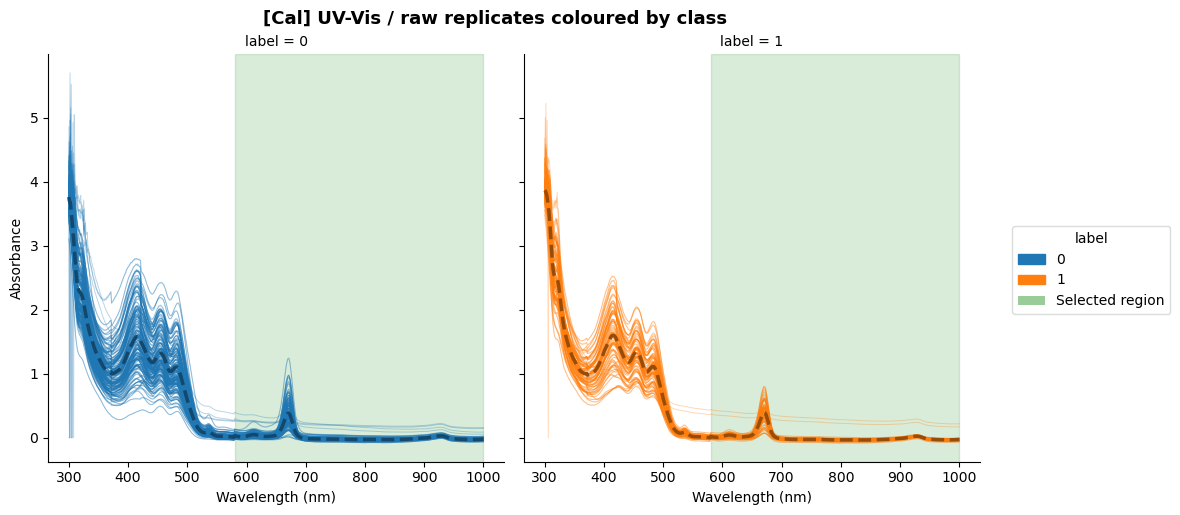

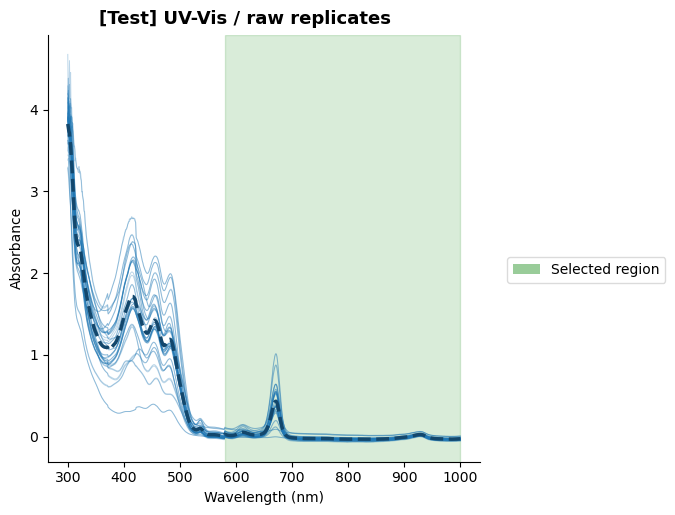

In [7]:
height = 5.0
aspect = 1.0

plot_spectra(
    data["cal_uvvis"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Cal] UV-Vis / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_uvvis"],
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Test] UV-Vis / raw replicates",
    height=height,
    aspect=aspect,
)

## FTIR

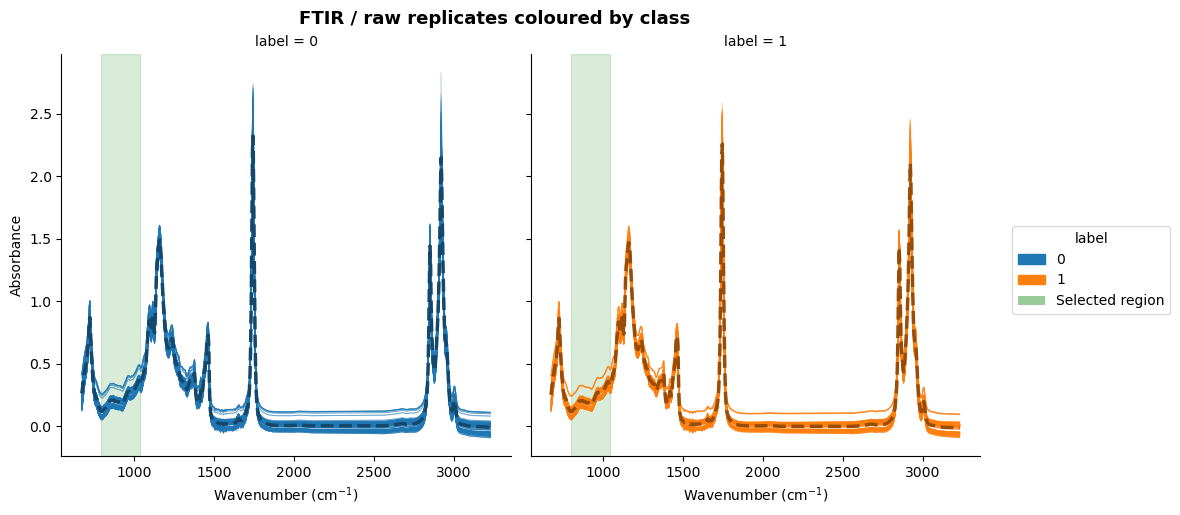

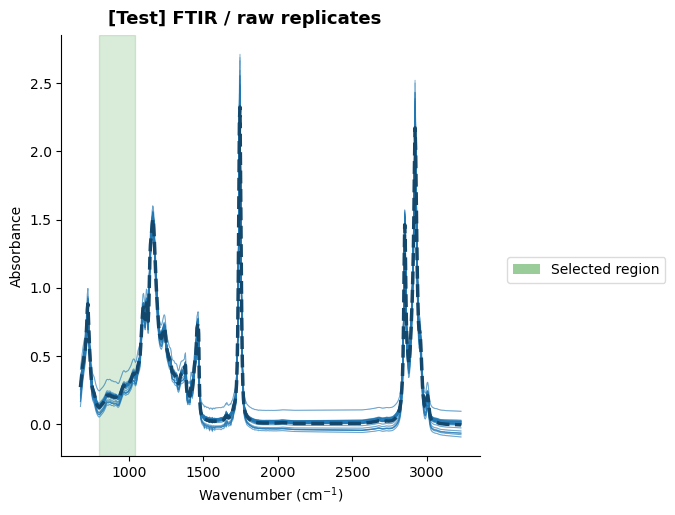

In [8]:
plot_spectra(
    data["cal_ftir"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="FTIR / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_ftir"],
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Test] FTIR / raw replicates",
    height=height,
    aspect=aspect,
)

## HS-MS

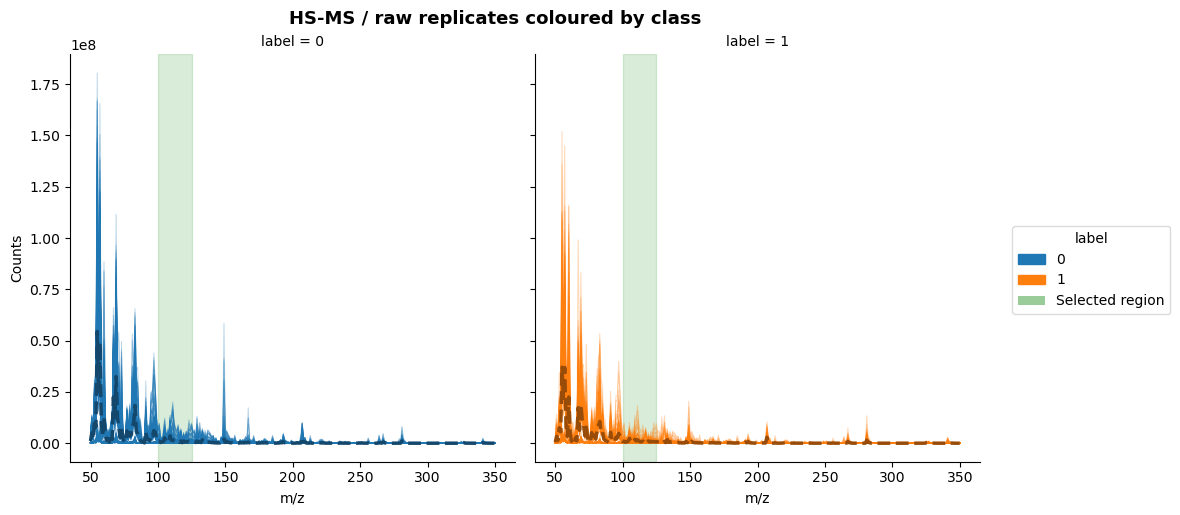

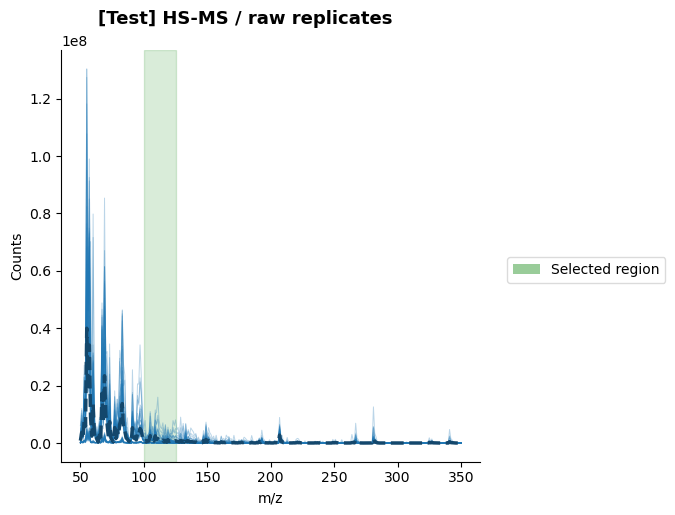

In [9]:
plot_spectra(
    data["cal_hsms"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="HS-MS / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_hsms"],
    show_mean=True,
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Test] HS-MS / raw replicates",
    height=height,
    aspect=aspect,
)

# Preprocessed spectra plots

## UV-Vis

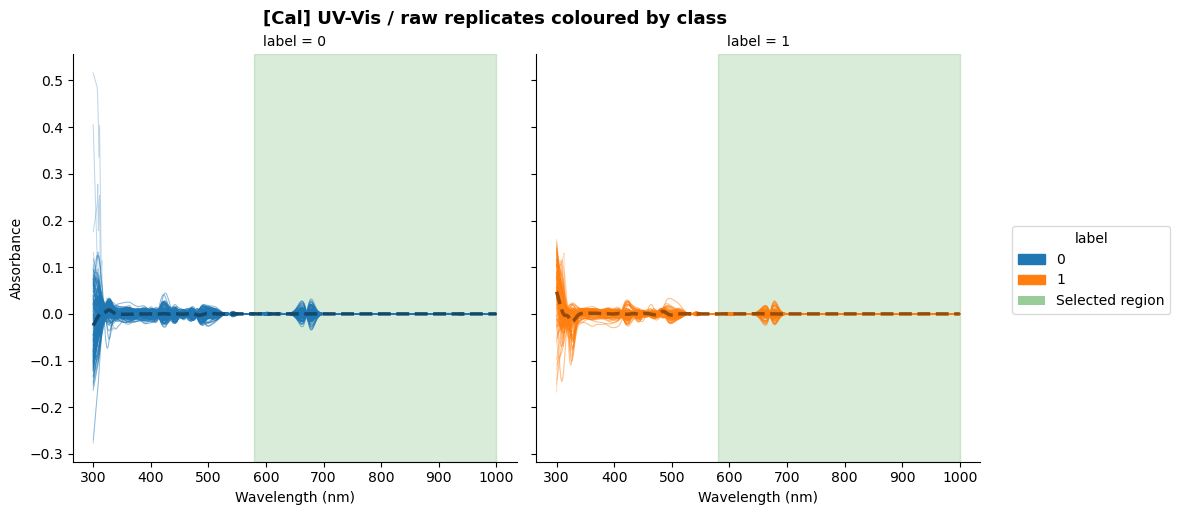

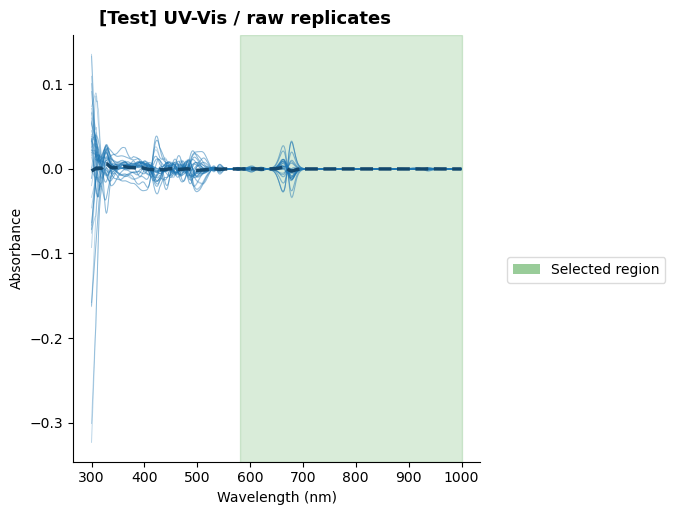

In [10]:
X_cal_uvvis = get_spectral_matrix(data["cal_uvvis"], average=False)
X_cal_uvvis = snv(X_cal_uvvis)
X_cal_uvvis = savgol_derivative(X_cal_uvvis)
X_cal_uvvis, X_cal_uvvis_centers = mean_center(X_cal_uvvis, center=None)

plot_spectra(
    X_cal_uvvis,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Cal] UV-Vis / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_uvvis = get_spectral_matrix(data["test_uvvis"], average=False)
X_test_uvvis = snv(X_test_uvvis)
X_test_uvvis = savgol_derivative(X_test_uvvis)
X_test_uvvis, _ = mean_center(X_test_uvvis, center=X_cal_uvvis_centers)

plot_spectra(
    X_test_uvvis,
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Test] UV-Vis / raw replicates",
    height=height,
    aspect=aspect,
)

## FTIR

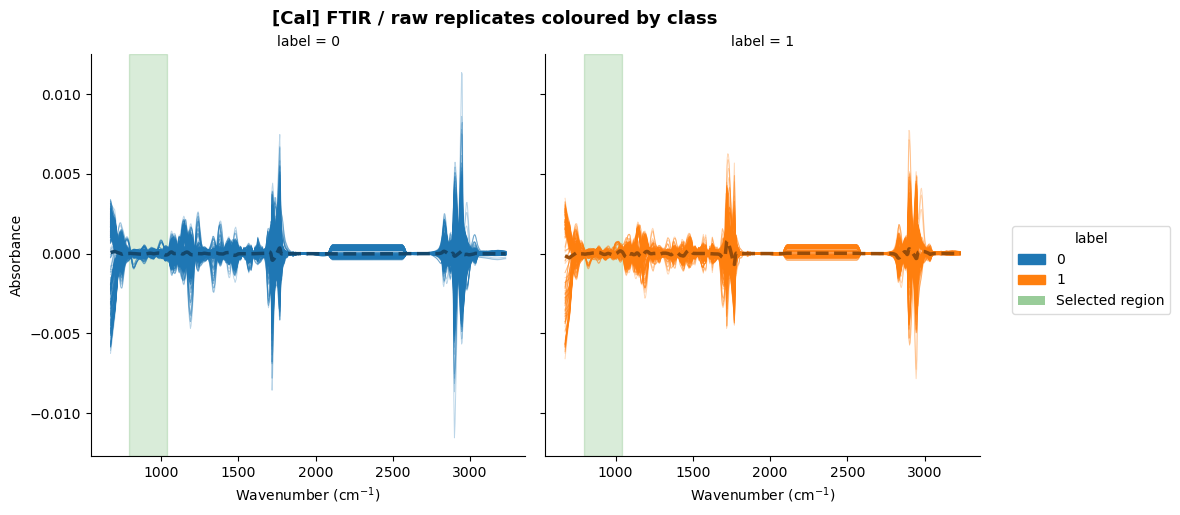

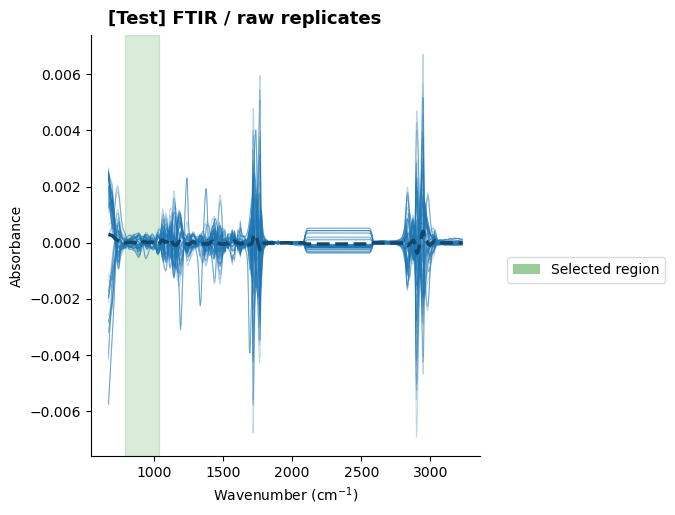

In [11]:
X_cal_ftir = get_spectral_matrix(data["cal_ftir"], average=False)
X_cal_ftir = snv(X_cal_ftir)
X_cal_ftir = savgol_derivative(X_cal_ftir)
X_cal_ftir, X_cal_ftir_centers = mean_center(X_cal_ftir, center=None)

plot_spectra(
    X_cal_ftir,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Cal] FTIR / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_ftir = get_spectral_matrix(data["test_ftir"], average=False)
X_test_ftir = snv(X_test_ftir)
X_test_ftir = savgol_derivative(X_test_ftir)
X_test_ftir, _ = mean_center(X_test_ftir, center=X_cal_ftir_centers)

plot_spectra(
    X_test_ftir,
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Test] FTIR / raw replicates",
    height=height,
    aspect=aspect,
)

## HS-MS

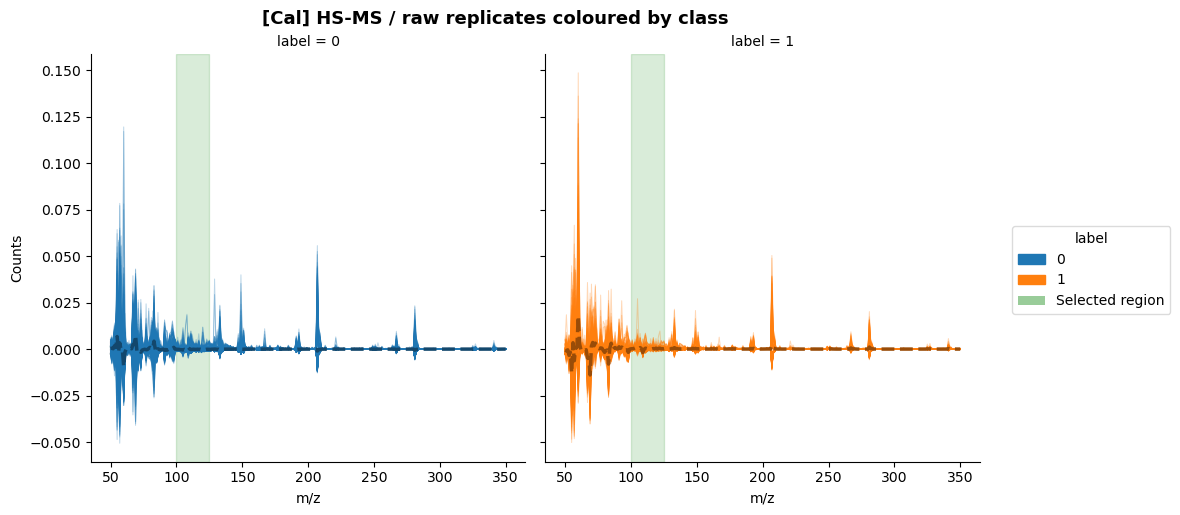

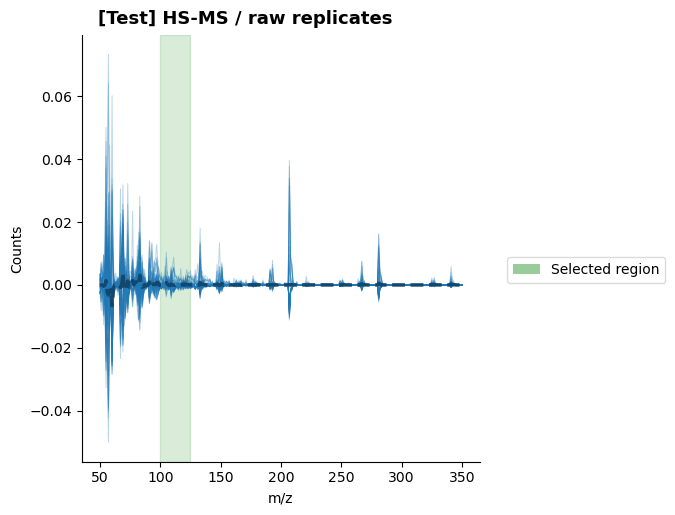

In [12]:
X_cal_hsms = get_spectral_matrix(data["cal_hsms"], average=False)
X_cal_hsms = row_profile(X_cal_hsms)
X_cal_hsms = log_transform(X_cal_hsms)
X_cal_hsms, X_cal_hsms_centers = mean_center(X_cal_hsms, center=None)

plot_spectra(
    X_cal_hsms,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Cal] HS-MS / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_hsms = get_spectral_matrix(data["test_hsms"], average=False)
X_test_hsms = row_profile(X_test_hsms)
X_test_hsms = log_transform(X_test_hsms)
X_test_hsms, _ = mean_center(X_test_hsms, center=X_cal_hsms_centers)

plot_spectra(
    X_test_hsms,
    show_mean=True,
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Test] HS-MS / raw replicates",
    height=height,
    aspect=aspect,
)

# PCA Outlier Detection

## UV-Vis

Restrict the spectrum, then preprocess averaged replicates (SNV → 1st derivative → mean-centre), fit a PCA model on the calibration set, and flag samples whose Hotelling's T² or Q-residuals exceed the control limits.

In [13]:
import matplotlib.pyplot as plt
from olive_oil.outliers import PCAOutlierDetector

# ── Configurable parameters ───────────────────────────────────────────────────
UVVIS_START        = 300    # nm  lower bound of selected region
UVVIS_END          = 1000   # nm  upper bound of selected region
N_COMPONENTS_UVVIS = 5      # number of PCA components (adjust from scree plot)
ALPHA              = 0.01   # significance level for control limits
# ─────────────────────────────────────────────────────────────────────────────

# Recompute the UV-Vis pipeline on averaged replicates (one row per sample)
X_cal_uvvis_avg = get_spectral_matrix(data["cal_uvvis"], average=True)
X_cal_uvvis_avg = select_region(X_cal_uvvis_avg, UVVIS_START, UVVIS_END)
X_cal_uvvis_avg = snv(X_cal_uvvis_avg)
X_cal_uvvis_avg = savgol_derivative(X_cal_uvvis_avg)
X_cal_uvvis_avg, _uvvis_center = mean_center(X_cal_uvvis_avg)

print(f"Calibration UV-Vis (averaged, {UVVIS_START}–{UVVIS_END} nm): "
      f"{X_cal_uvvis_avg[0].shape[0]} samples × {X_cal_uvvis_avg[0].shape[1]} wavelengths")

Calibration UV-Vis (averaged, 300–1000 nm): 220 samples × 701 wavelengths


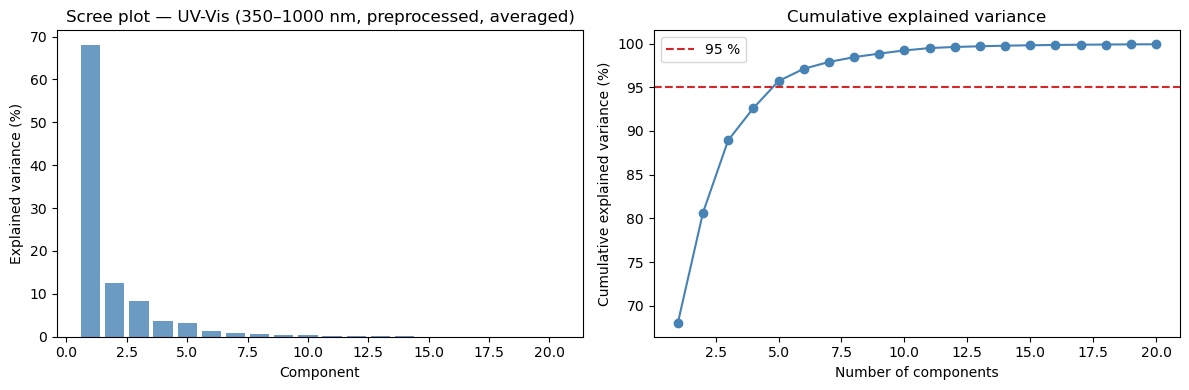

In [14]:
from sklearn.decomposition import PCA as _SklearnPCA

_pca_full = _SklearnPCA().fit(X_cal_uvvis_avg[0])
cumvar = np.cumsum(_pca_full.explained_variance_ratio_) * 100
n_show = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_show + 1),
            _pca_full.explained_variance_ratio_[:n_show] * 100,
            color="steelblue", alpha=0.8)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Scree plot — UV-Vis (350–1000 nm, preprocessed, averaged)")

axes[1].plot(range(1, n_show + 1), cumvar[:n_show], marker="o", color="steelblue")
axes[1].axhline(95, color="tab:red", linestyle="--", label="95 %")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()

In [15]:
detector_uvvis = PCAOutlierDetector(n_components=N_COMPONENTS_UVVIS)
detector_uvvis.fit(X_cal_uvvis_avg)
result_uvvis = detector_uvvis.flag_outliers(X_cal_uvvis_avg, alpha=ALPHA)

df_uvvis = (
    pd.DataFrame({
        "sample_id": result_uvvis.sample_ids,
        "T2":        result_uvvis.t2,
        "Q":         result_uvvis.q,
        "outlier":   result_uvvis.flags,
    })
    .merge(meta[["sample_id", "label"]], on="sample_id", how="left")
)

print(f"T² limit ({int((1 - ALPHA) * 100)} %): {result_uvvis.t2_limit:.3f}")
print(f"Q  limit ({int((1 - ALPHA) * 100)} %): {result_uvvis.q_limit:.4f}")
print(f"\nOutliers detected: {result_uvvis.flags.sum()} / {len(result_uvvis.sample_ids)}")
if result_uvvis.flags.any():
    print()
    print(df_uvvis.loc[df_uvvis["outlier"], ["sample_id", "T2", "Q", "label"]].to_string(index=False))

T² limit (99 %): 15.878
Q  limit (99 %): 0.0095

Outliers detected: 13 / 220

sample_id        T2        Q  label
        3 21.288360 0.001363      1
       11 11.759412 0.020568      0
       22 11.678041 0.009494      0
       41 11.254153 0.017706      0
       44  4.330872 0.014440      1
       76 28.487018 0.005692      1
       77 17.277828 0.017383      1
       78 13.531670 0.011096      0
      106 14.365936 0.012655      0
      107 69.949455 0.019347      0
      157  1.700017 0.011471      0
      167  2.050590 0.010647      0
      204 20.981168 0.002705      1


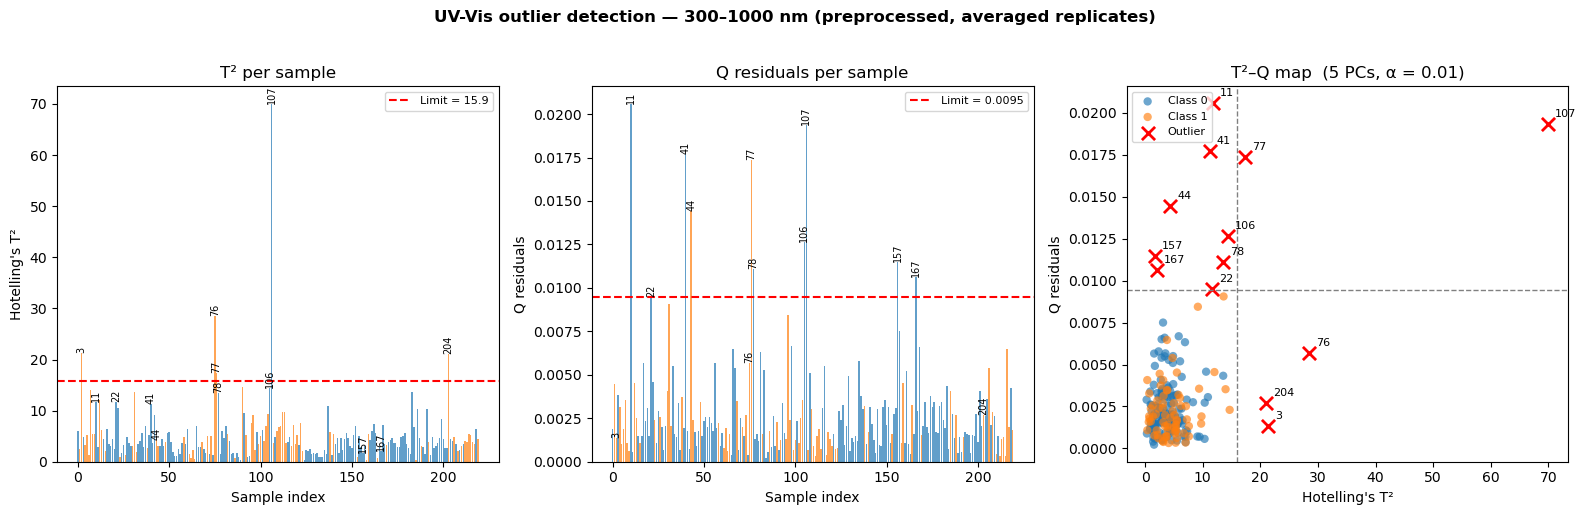

In [16]:
pal = {0: "tab:blue", 1: "tab:orange"}
outlier_mask = df_uvvis["outlier"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- T² per sample ---
ax = axes[0]
ax.bar(range(len(df_uvvis)), df_uvvis["T2"],
       color=[pal.get(l, "gray") for l in df_uvvis["label"]], alpha=0.7)
ax.axhline(result_uvvis.t2_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_uvvis.t2_limit:.1f}")
for i, (flag, sid) in enumerate(zip(outlier_mask, df_uvvis["sample_id"])):
    if flag:
        ax.text(i, df_uvvis["T2"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Hotelling's T²")
ax.set_title("T² per sample")
ax.legend(fontsize=8)

# --- Q per sample ---
ax = axes[1]
ax.bar(range(len(df_uvvis)), df_uvvis["Q"],
       color=[pal.get(l, "gray") for l in df_uvvis["label"]], alpha=0.7)
ax.axhline(result_uvvis.q_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_uvvis.q_limit:.4f}")
for i, (flag, sid) in enumerate(zip(outlier_mask, df_uvvis["sample_id"])):
    if flag:
        ax.text(i, df_uvvis["Q"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Q residuals")
ax.set_title("Q residuals per sample")
ax.legend(fontsize=8)

# --- T²–Q scatter ---
ax = axes[2]
for label_val, color in pal.items():
    mask = (df_uvvis["label"] == label_val) & ~outlier_mask
    ax.scatter(df_uvvis.loc[mask, "T2"], df_uvvis.loc[mask, "Q"],
               color=color, alpha=0.65, edgecolors="none",
               label=f"Class {label_val}")
ax.scatter(df_uvvis.loc[outlier_mask, "T2"], df_uvvis.loc[outlier_mask, "Q"],
           color="red", marker="x", s=90, lw=2, label="Outlier")
for _, row in df_uvvis[df_uvvis["outlier"]].iterrows():
    ax.annotate(row["sample_id"], (row["T2"], row["Q"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.axvline(result_uvvis.t2_limit, color="gray", linestyle="--", lw=1)
ax.axhline(result_uvvis.q_limit, color="gray", linestyle="--", lw=1)
ax.set_xlabel("Hotelling's T²")
ax.set_ylabel("Q residuals")
ax.set_title(f"T²–Q map  ({N_COMPONENTS_UVVIS} PCs, α = {ALPHA})")
ax.legend(fontsize=8)

plt.suptitle(f"UV-Vis outlier detection — {UVVIS_START}–{UVVIS_END} nm (preprocessed, averaged replicates)",
             fontweight="bold", y=1.02)
plt.tight_layout()

## ATR-FTIR

Restrict the spectrum, then preprocess averaged replicates (SNV → 1st derivative → mean-centre), fit a PCA model on the calibration set, and flag samples whose Hotelling's T² or Q-residuals exceed the control limits.

In [17]:
# ── Configurable parameters ───────────────────────────────────────────────────
FTIR_START        = 700    # cm⁻¹  lower bound of selected region
FTIR_END          = 1500   # cm⁻¹  upper bound of selected region
N_COMPONENTS_FTIR = 6      # number of PCA components (adjust from scree plot)
ALPHA        = 0.01   # significance level for control limits
# ─────────────────────────────────────────────────────────────────────────────

X_cal_ftir_avg = get_spectral_matrix(data["cal_ftir"], average=True)
X_cal_ftir_avg = select_region(X_cal_ftir_avg, FTIR_START, FTIR_END)
X_cal_ftir_avg = snv(X_cal_ftir_avg)
X_cal_ftir_avg = savgol_derivative(X_cal_ftir_avg)
X_cal_ftir_avg, _ftir_center = mean_center(X_cal_ftir_avg)

print(f"Calibration ATR-FTIR (averaged, {FTIR_START}–{FTIR_END} cm⁻¹): "
      f"{X_cal_ftir_avg[0].shape[0]} samples × {X_cal_ftir_avg[0].shape[1]} wavenumbers")

Calibration ATR-FTIR (averaged, 700–1500 cm⁻¹): 220 samples × 208 wavenumbers


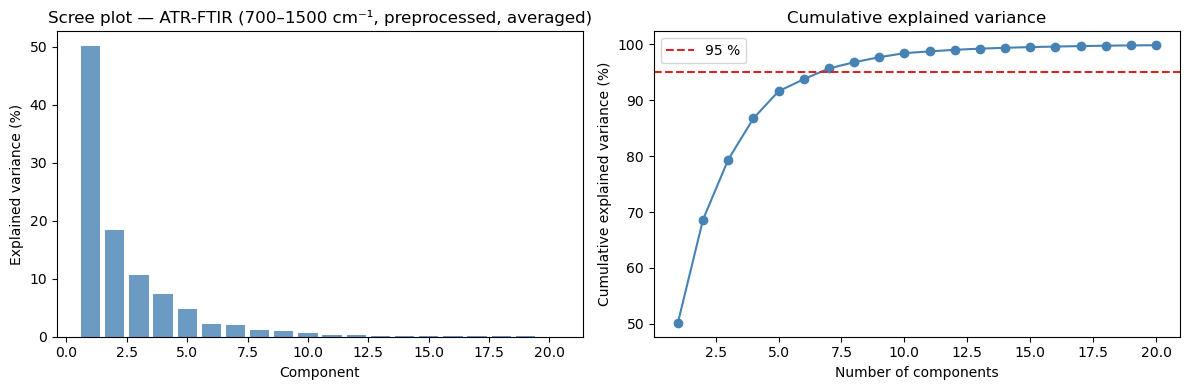

In [18]:
from sklearn.decomposition import PCA as _SklearnPCA

_pca_ftir_full = _SklearnPCA().fit(X_cal_ftir_avg[0])
cumvar_ftir = np.cumsum(_pca_ftir_full.explained_variance_ratio_) * 100
n_show = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_show + 1),
            _pca_ftir_full.explained_variance_ratio_[:n_show] * 100,
            color="steelblue", alpha=0.8)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title(f"Scree plot — ATR-FTIR ({FTIR_START}–{FTIR_END} cm⁻¹, preprocessed, averaged)")

axes[1].plot(range(1, n_show + 1), cumvar_ftir[:n_show], marker="o", color="steelblue")
axes[1].axhline(95, color="tab:red", linestyle="--", label="95 %")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()

In [19]:
detector_ftir = PCAOutlierDetector(n_components=N_COMPONENTS_FTIR)
detector_ftir.fit(X_cal_ftir_avg)
result_ftir = detector_ftir.flag_outliers(X_cal_ftir_avg, alpha=ALPHA)

df_ftir = (
    pd.DataFrame({
        "sample_id": result_ftir.sample_ids,
        "T2":        result_ftir.t2,
        "Q":         result_ftir.q,
        "outlier":   result_ftir.flags,
    })
    .merge(meta[["sample_id", "label"]], on="sample_id", how="left")
)

print(f"T² limit ({int((1 - ALPHA) * 100)} %): {result_ftir.t2_limit:.3f}")
print(f"Q  limit ({int((1 - ALPHA) * 100)} %): {result_ftir.q_limit:.4f}")
print(f"\nOutliers detected: {result_ftir.flags.sum()} / {len(result_ftir.sample_ids)}")
if result_ftir.flags.any():
    print()
    print(df_ftir.loc[df_ftir["outlier"], ["sample_id", "T2", "Q", "label"]].to_string(index=False))

T² limit (99 %): 17.809
Q  limit (99 %): 0.0000

Outliers detected: 13 / 220

sample_id        T2        Q  label
        2 42.647452 0.000019      1
        8 22.331411 0.000011      1
       30 23.516813 0.000016      0
       94 20.346319 0.000002      0
       96 20.013028 0.000003      1
       99 19.046226 0.000002      0
      100 20.226183 0.000004      1
      181 24.756449 0.000002      0
      182 55.981887 0.000003      0
      183 21.757885 0.000003      0
      185 18.718459 0.000011      0
      187 21.763648 0.000002      0
      191 18.440649 0.000007      0


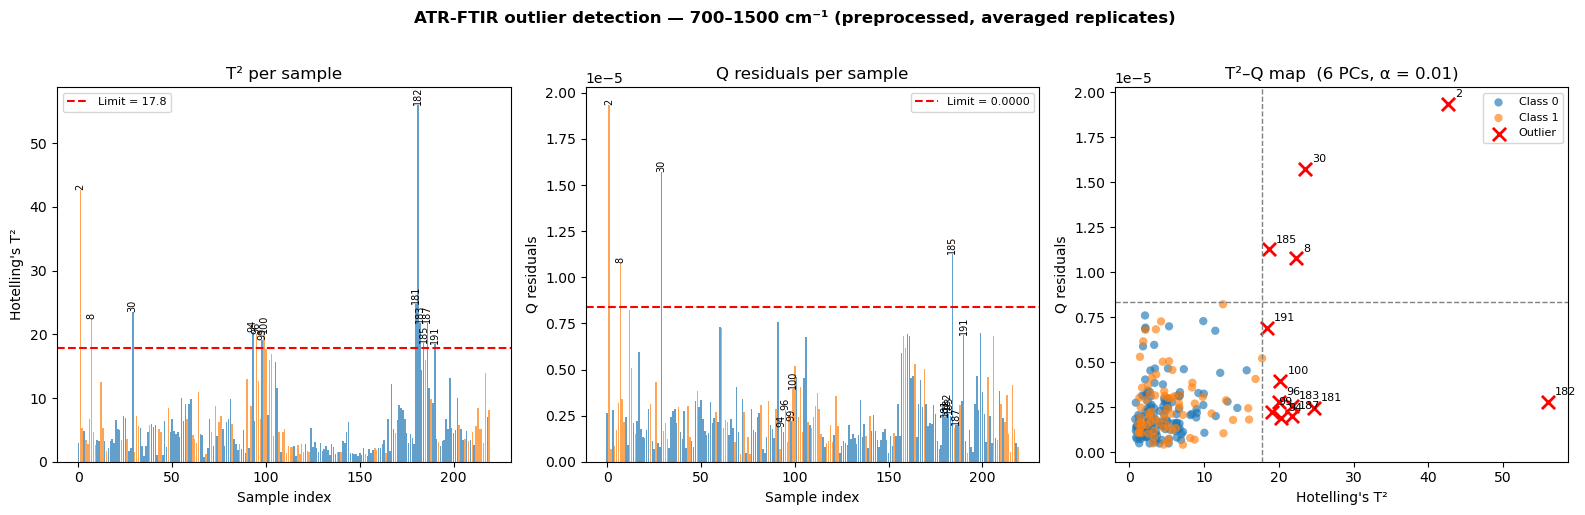

In [20]:
pal_ftir = {0: "tab:blue", 1: "tab:orange"}
outlier_mask_ftir = df_ftir["outlier"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- T² per sample ---
ax = axes[0]
ax.bar(range(len(df_ftir)), df_ftir["T2"],
       color=[pal_ftir.get(l, "gray") for l in df_ftir["label"]], alpha=0.7)
ax.axhline(result_ftir.t2_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_ftir.t2_limit:.1f}")
for i, (flag, sid) in enumerate(zip(outlier_mask_ftir, df_ftir["sample_id"])):
    if flag:
        ax.text(i, df_ftir["T2"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Hotelling's T²")
ax.set_title("T² per sample")
ax.legend(fontsize=8)

# --- Q per sample ---
ax = axes[1]
ax.bar(range(len(df_ftir)), df_ftir["Q"],
       color=[pal_ftir.get(l, "gray") for l in df_ftir["label"]], alpha=0.7)
ax.axhline(result_ftir.q_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_ftir.q_limit:.4f}")
for i, (flag, sid) in enumerate(zip(outlier_mask_ftir, df_ftir["sample_id"])):
    if flag:
        ax.text(i, df_ftir["Q"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Q residuals")
ax.set_title("Q residuals per sample")
ax.legend(fontsize=8)

# --- T²–Q scatter ---
ax = axes[2]
for label_val, color in pal_ftir.items():
    mask = (df_ftir["label"] == label_val) & ~outlier_mask_ftir
    ax.scatter(df_ftir.loc[mask, "T2"], df_ftir.loc[mask, "Q"],
               color=color, alpha=0.65, edgecolors="none",
               label=f"Class {label_val}")
ax.scatter(df_ftir.loc[outlier_mask_ftir, "T2"], df_ftir.loc[outlier_mask_ftir, "Q"],
           color="red", marker="x", s=90, lw=2, label="Outlier")
for _, row in df_ftir[df_ftir["outlier"]].iterrows():
    ax.annotate(row["sample_id"], (row["T2"], row["Q"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.axvline(result_ftir.t2_limit, color="gray", linestyle="--", lw=1)
ax.axhline(result_ftir.q_limit, color="gray", linestyle="--", lw=1)
ax.set_xlabel("Hotelling's T²")
ax.set_ylabel("Q residuals")
ax.set_title(f"T²–Q map  ({N_COMPONENTS_FTIR} PCs, α = {ALPHA})")
ax.legend(fontsize=8)

plt.suptitle(f"ATR-FTIR outlier detection — {FTIR_START}–{FTIR_END} cm⁻¹ (preprocessed, averaged replicates)",
             fontweight="bold", y=1.02)
plt.tight_layout()

## HS-MS

Restrict the spectrum, then preprocess averaged replicates (row profiling → log transform → mean-centre), fit a PCA model on the calibration set, and flag samples whose Hotelling's T² or Q-residuals exceed the control limits.

In [21]:
# ── Configurable parameters ───────────────────────────────────────────────────
HSMS_START        = 100     # m/z  lower bound of selected region
HSMS_END          = 125    # m/z  upper bound of selected region
N_COMPONENTS_HSMS = 9      # number of PCA components (adjust from scree plot)
ALPHA        = 0.01   # significance level for control limits
# ─────────────────────────────────────────────────────────────────────────────

X_cal_hsms_avg = get_spectral_matrix(data["cal_hsms"], average=True)
X_cal_hsms_avg = select_region(X_cal_hsms_avg, HSMS_START, HSMS_END)
X_cal_hsms_avg = row_profile(X_cal_hsms_avg)
X_cal_hsms_avg = log_transform(X_cal_hsms_avg)
X_cal_hsms_avg, _hsms_center = mean_center(X_cal_hsms_avg)

print(f"Calibration HS-MS (averaged, {HSMS_START}–{HSMS_END} m/z): "
      f"{X_cal_hsms_avg[0].shape[0]} samples × {X_cal_hsms_avg[0].shape[1]} variables")

Calibration HS-MS (averaged, 100–125 m/z): 220 samples × 26 variables


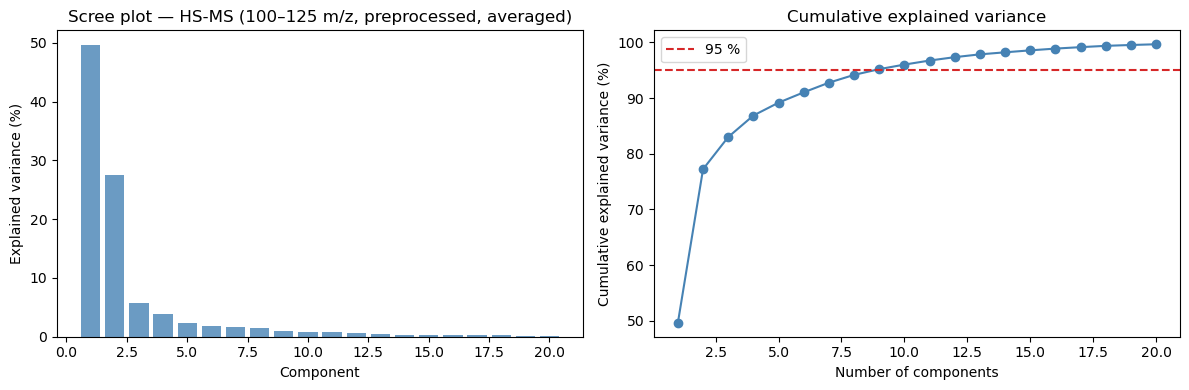

In [22]:
from sklearn.decomposition import PCA as _SklearnPCA

_pca_hsms_full = _SklearnPCA().fit(X_cal_hsms_avg[0])
cumvar_hsms = np.cumsum(_pca_hsms_full.explained_variance_ratio_) * 100
n_show = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_show + 1),
            _pca_hsms_full.explained_variance_ratio_[:n_show] * 100,
            color="steelblue", alpha=0.8)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title(f"Scree plot — HS-MS ({HSMS_START}–{HSMS_END} m/z, preprocessed, averaged)")

axes[1].plot(range(1, n_show + 1), cumvar_hsms[:n_show], marker="o", color="steelblue")
axes[1].axhline(95, color="tab:red", linestyle="--", label="95 %")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()

In [23]:
detector_hsms = PCAOutlierDetector(n_components=N_COMPONENTS_HSMS)
detector_hsms.fit(X_cal_hsms_avg)
result_hsms = detector_hsms.flag_outliers(X_cal_hsms_avg, alpha=ALPHA)

df_hsms = (
    pd.DataFrame({
        "sample_id": result_hsms.sample_ids,
        "T2":        result_hsms.t2,
        "Q":         result_hsms.q,
        "outlier":   result_hsms.flags,
    })
    .merge(meta[["sample_id", "label"]], on="sample_id", how="left")
)

print(f"T² limit ({int((1 - ALPHA) * 100)} %): {result_hsms.t2_limit:.3f}")
print(f"Q  limit ({int((1 - ALPHA) * 100)} %): {result_hsms.q_limit:.4f}")
print(f"\nOutliers detected: {result_hsms.flags.sum()} / {len(result_hsms.sample_ids)}")
if result_hsms.flags.any():
    print()
    print(df_hsms.loc[df_hsms["outlier"], ["sample_id", "T2", "Q", "label"]].to_string(index=False))

T² limit (99 %): 23.387
Q  limit (99 %): 0.0011

Outliers detected: 23 / 220

sample_id         T2        Q  label
        5  11.572641 0.001560      1
        8  26.416263 0.001275      1
       13   9.042456 0.001928      1
       14  39.177045 0.001514      1
       15  29.021618 0.001251      0
       18  27.874982 0.000939      0
       21  23.490010 0.000421      0
       22  40.553937 0.000522      0
       23 128.381643 0.004182      0
       29  26.922170 0.003109      0
       38  21.591572 0.001684      0
       42  76.995128 0.000692      0
       43  75.494443 0.001685      0
       44  48.512480 0.001468      1
       47  12.425739 0.001499      0
       49  10.940677 0.001865      1
       52  39.887409 0.000607      0
       74  30.690052 0.002199      1
       76  17.709213 0.001258      1
       79   9.972166 0.001548      0
       82  11.822763 0.001112      0
       91  26.075903 0.001482      1
      127  28.823755 0.000364      0


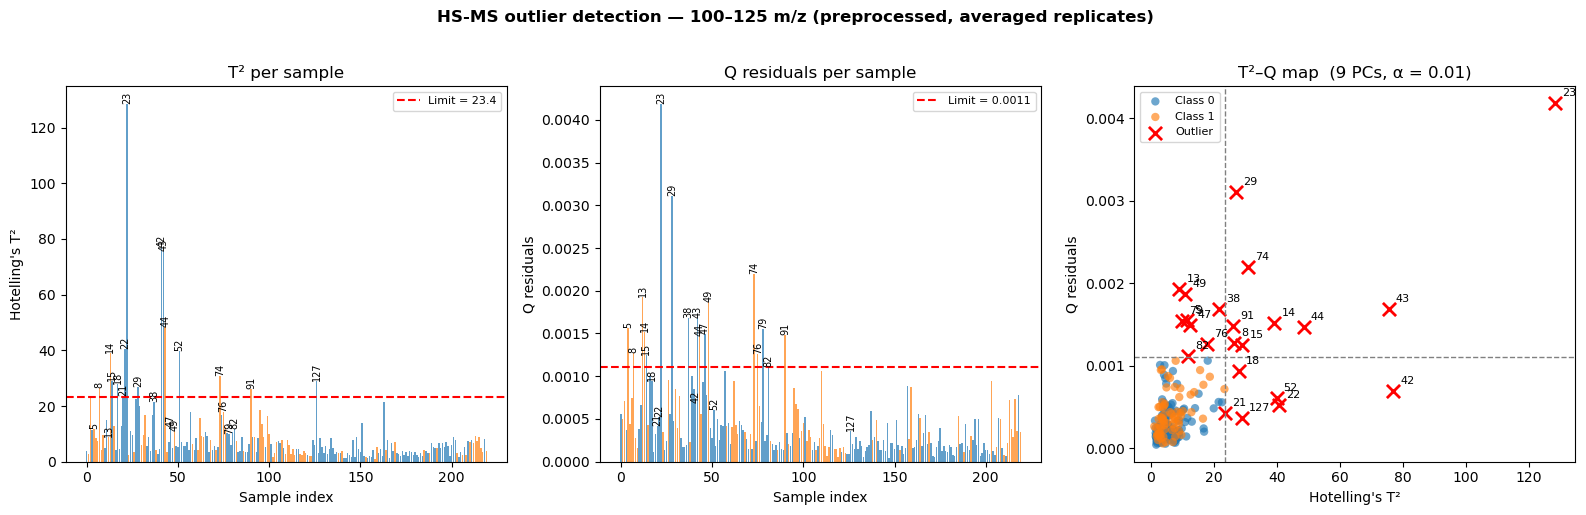

In [24]:
pal_hsms = {0: "tab:blue", 1: "tab:orange"}
outlier_mask_hsms = df_hsms["outlier"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- T² per sample ---
ax = axes[0]
ax.bar(range(len(df_hsms)), df_hsms["T2"],
       color=[pal_hsms.get(l, "gray") for l in df_hsms["label"]], alpha=0.7)
ax.axhline(result_hsms.t2_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_hsms.t2_limit:.1f}")
for i, (flag, sid) in enumerate(zip(outlier_mask_hsms, df_hsms["sample_id"])):
    if flag:
        ax.text(i, df_hsms["T2"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Hotelling's T²")
ax.set_title("T² per sample")
ax.legend(fontsize=8)

# --- Q per sample ---
ax = axes[1]
ax.bar(range(len(df_hsms)), df_hsms["Q"],
       color=[pal_hsms.get(l, "gray") for l in df_hsms["label"]], alpha=0.7)
ax.axhline(result_hsms.q_limit, color="red", linestyle="--", lw=1.5,
           label=f"Limit = {result_hsms.q_limit:.4f}")
for i, (flag, sid) in enumerate(zip(outlier_mask_hsms, df_hsms["sample_id"])):
    if flag:
        ax.text(i, df_hsms["Q"].iloc[i], sid, rotation=90,
                ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Sample index")
ax.set_ylabel("Q residuals")
ax.set_title("Q residuals per sample")
ax.legend(fontsize=8)

# --- T²–Q scatter ---
ax = axes[2]
for label_val, color in pal_hsms.items():
    mask = (df_hsms["label"] == label_val) & ~outlier_mask_hsms
    ax.scatter(df_hsms.loc[mask, "T2"], df_hsms.loc[mask, "Q"],
               color=color, alpha=0.65, edgecolors="none",
               label=f"Class {label_val}")
ax.scatter(df_hsms.loc[outlier_mask_hsms, "T2"], df_hsms.loc[outlier_mask_hsms, "Q"],
           color="red", marker="x", s=90, lw=2, label="Outlier")
for _, row in df_hsms[df_hsms["outlier"]].iterrows():
    ax.annotate(row["sample_id"], (row["T2"], row["Q"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.axvline(result_hsms.t2_limit, color="gray", linestyle="--", lw=1)
ax.axhline(result_hsms.q_limit, color="gray", linestyle="--", lw=1)
ax.set_xlabel("Hotelling's T²")
ax.set_ylabel("Q residuals")
ax.set_title(f"T²–Q map  ({N_COMPONENTS_HSMS} PCs, α = {ALPHA})")
ax.legend(fontsize=8)

plt.suptitle(f"HS-MS outlier detection — {HSMS_START}–{HSMS_END} m/z (preprocessed, averaged replicates)",
             fontweight="bold", y=1.02)
plt.tight_layout()

# Cross-Block Outlier Summary

Aggregate results across all three spectral domains. The **union** (cross-block discard rule) is the set of samples to remove before modelling; the **intersection** are the most extreme samples flagged by every technique.

In [25]:
def _sort_ids(ids):
    """Sort sample IDs numerically if possible, lexicographically otherwise."""
    try:
        return sorted(ids, key=int)
    except (ValueError, TypeError):
        return sorted(str(s) for s in ids)

# Per-block outlier sets
ids_uvvis = set(result_uvvis.outlier_ids)
ids_ftir  = set(result_ftir.outlier_ids)
ids_hsms  = set(result_hsms.outlier_ids)

ids_union        = ids_uvvis | ids_ftir | ids_hsms
ids_intersection = ids_uvvis & ids_ftir & ids_hsms

blocks = {
    "UV-Vis":    (ids_uvvis, f"350–1000 nm,        α={ALPHA}"),
    "ATR-FTIR":  (ids_ftir,  f"{FTIR_START}–{FTIR_END} cm⁻¹,   α={ALPHA}"),
    "HS-MS":     (ids_hsms,  f"{HSMS_START}–{HSMS_END} m/z,       α={ALPHA}"),
}

W = 68
print("=" * W)
print("  PCA Outlier Detection — Cross-Block Summary")
print("=" * W)

for block_name, (ids, params) in blocks.items():
    id_str = ", ".join(_sort_ids(ids)) if ids else "none"
    print(f"\n  {block_name}  ({params})")
    print(f"    {len(ids)} outlier(s): {id_str}")

print("\n" + "─" * W)
print(f"\n  Union  — flagged in ≥ 1 block  →  {len(ids_union)} sample(s)")
for sid in _sort_ids(ids_union):
    flagged_in = [name for name, (ids, _) in blocks.items() if sid in ids]
    print(f"    {str(sid):>6}   ←  {' + '.join(flagged_in)}")

print(f"\n  Intersection  — flagged in all 3 blocks  →  {len(ids_intersection)} sample(s)")
if ids_intersection:
    print(f"    {', '.join(_sort_ids(ids_intersection))}")
else:
    print("    none")

print("\n" + "=" * W)

  PCA Outlier Detection — Cross-Block Summary

  UV-Vis  (350–1000 nm,        α=0.01)
    13 outlier(s): 3, 11, 22, 41, 44, 76, 77, 78, 106, 107, 157, 167, 204

  ATR-FTIR  (700–1500 cm⁻¹,   α=0.01)
    13 outlier(s): 2, 8, 30, 94, 96, 99, 100, 181, 182, 183, 185, 187, 191

  HS-MS  (100–125 m/z,       α=0.01)
    23 outlier(s): 5, 8, 13, 14, 15, 18, 21, 22, 23, 29, 38, 42, 43, 44, 47, 49, 52, 74, 76, 79, 82, 91, 127

────────────────────────────────────────────────────────────────────

  Union  — flagged in ≥ 1 block  →  45 sample(s)
         2   ←  ATR-FTIR
         3   ←  UV-Vis
         5   ←  HS-MS
         8   ←  ATR-FTIR + HS-MS
        11   ←  UV-Vis
        13   ←  HS-MS
        14   ←  HS-MS
        15   ←  HS-MS
        18   ←  HS-MS
        21   ←  HS-MS
        22   ←  UV-Vis + HS-MS
        23   ←  HS-MS
        29   ←  HS-MS
        30   ←  ATR-FTIR
        38   ←  HS-MS
        41   ←  UV-Vis
        42   ←  HS-MS
        43   ←  HS-MS
        44   ←  UV-Vis + HS-MS
   